# Lab 1: Statistical Foundations & Classical Models

## Objective
Apply concepts from Lecture 1 to the Air Passengers dataset:
1. Time Series Decomposition.
2. Testing for Stationarity (ADF Test).
3. Interpreting ACF and PACF plots.
4. Building and evaluating an ARIMA model.

In [1]:
import kagglehub
path = kagglehub.dataset_download("rakannimer/air-passengers", output_dir="dataset/")
print("Path to dataset files:", path)

Path to dataset files: dataset/


            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


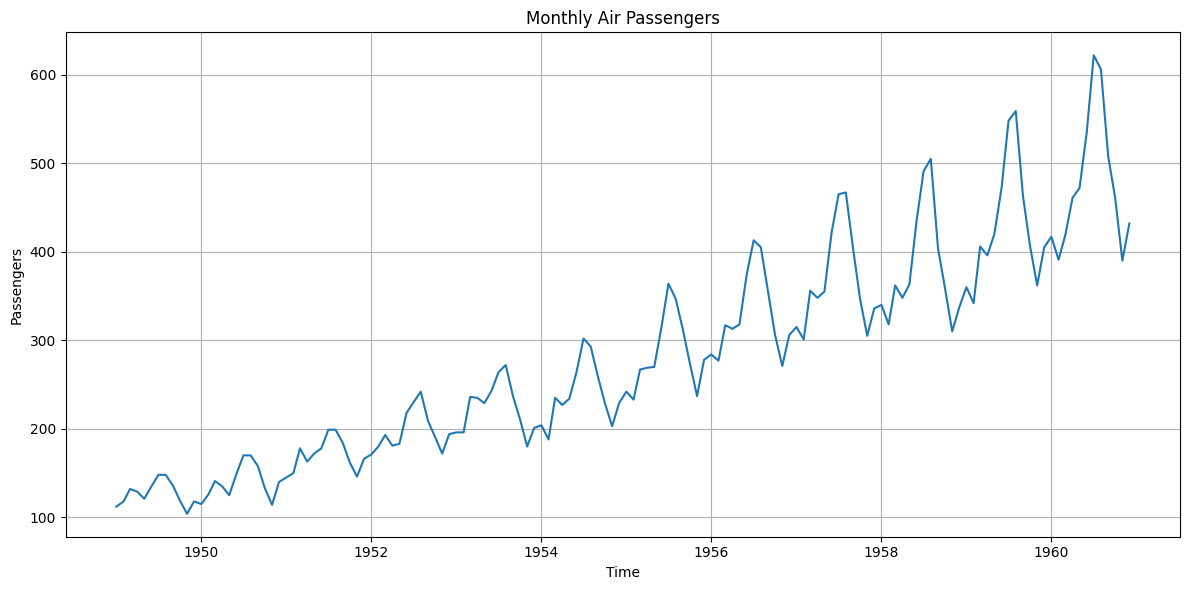

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['axes.grid'] = True 
# Load Data
df = pd.read_csv('dataset/AirPassengers.csv')
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)
df.columns = ['Passengers']

print(df.head())

# Plot Raw Data
ax = plt.subplot()
ax.plot(df.index, df['Passengers'])
ax.set_title("Monthly Air Passengers")
ax.set_xlabel("Time")
ax.set_ylabel("Passengers")
plt.tight_layout()
plt.show()

### Part 2: Time Series Decomposition
The "Megaphone Effect" (increasing variance) suggests a Multiplicative model.

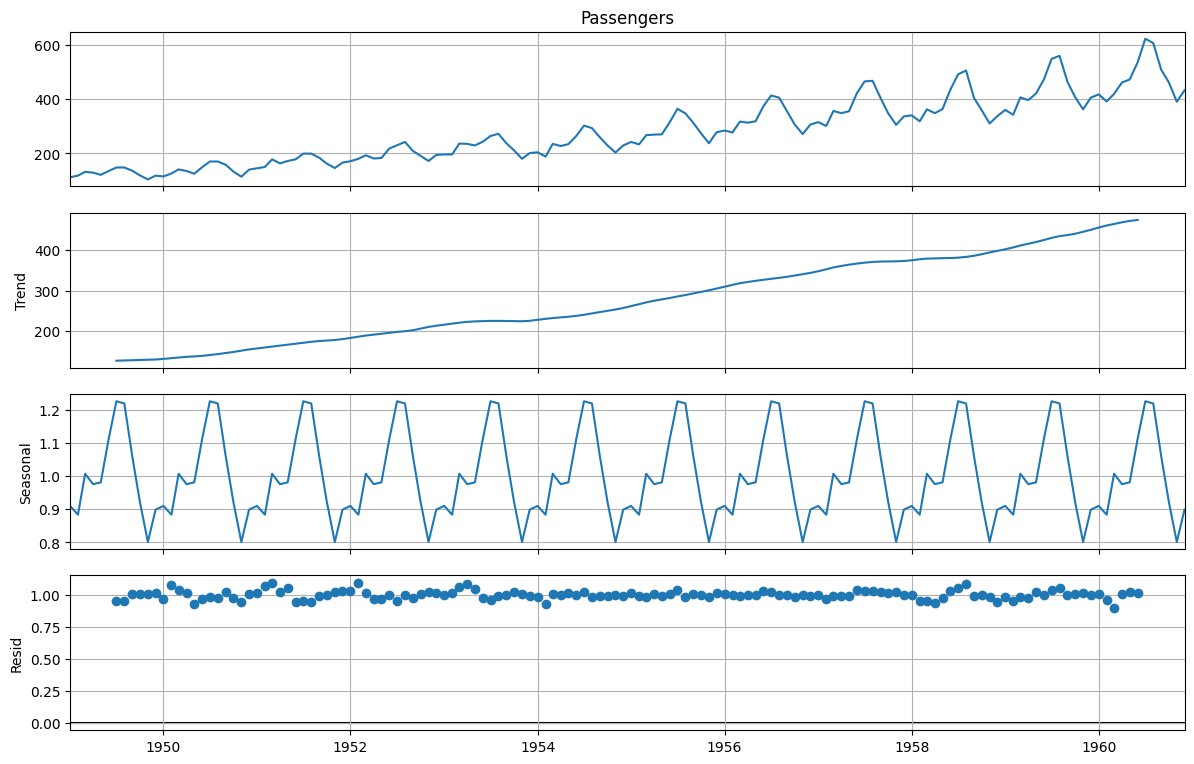

In [3]:
decomposition = seasonal_decompose(df['Passengers'], model='multiplicative', period=12)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

### Part 3: Stationarity
Check stationarity using the Augmented Dickey-Fuller (ADF) test.
- H0: Data is Non-Stationary.
- H1: Data is Stationary.

In [21]:
def adf_test(series):
    """ADF Reject Nulls When
    - Statistic < Critical Value(5%)
    - P-value < 0.05
    """
    result = adfuller(series, autolag='BIC')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print(f"Critical Values:")
    for k, v in  result[4].items():
        print(f"{k}: {v:.4f}")
    if result[1] < 0.05 and result[0] < result[4]['5%']:
        print("Result: Data is STATIONARY (Reject H0)")
    else:
        print("Result: Data is NON-STATIONARY (Fail to reject H0)")


def kpss_test(series):
    """KPSS Reject Nulls When
    - Statistic > Critical Value(5%)
    - P-value < 0.05
    """
    result = kpss(series, regression='c', nlags='auto')
    print(f'KPSS Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print(f"Critical Values:")
    for k, v in  result[3].items():
        print(f"{k}: {v:.4f}")
    
    if result[1] < 0.05 and result[0] > result[3]['5%']:
        print("Result: Data is NON-STATIONARY (Reject H0)")
    else:
        print("Result: Data is STATIONARY (Fail to reject H0)")

print("--- Raw Data Test ---")
adf_test(df['Passengers'])
print("-"*50)
kpss_test(df['Passengers'])

--- Raw Data Test ---
ADF Statistic: 0.8154
p-value: 0.9919
Critical Values:
1%: -3.4817
5%: -2.8840
10%: -2.5788
Result: Data is NON-STATIONARY (Fail to reject H0)
--------------------------------------------------
KPSS Statistic: 1.6513
p-value: 0.0100
Critical Values:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390
Result: Data is NON-STATIONARY (Reject H0)


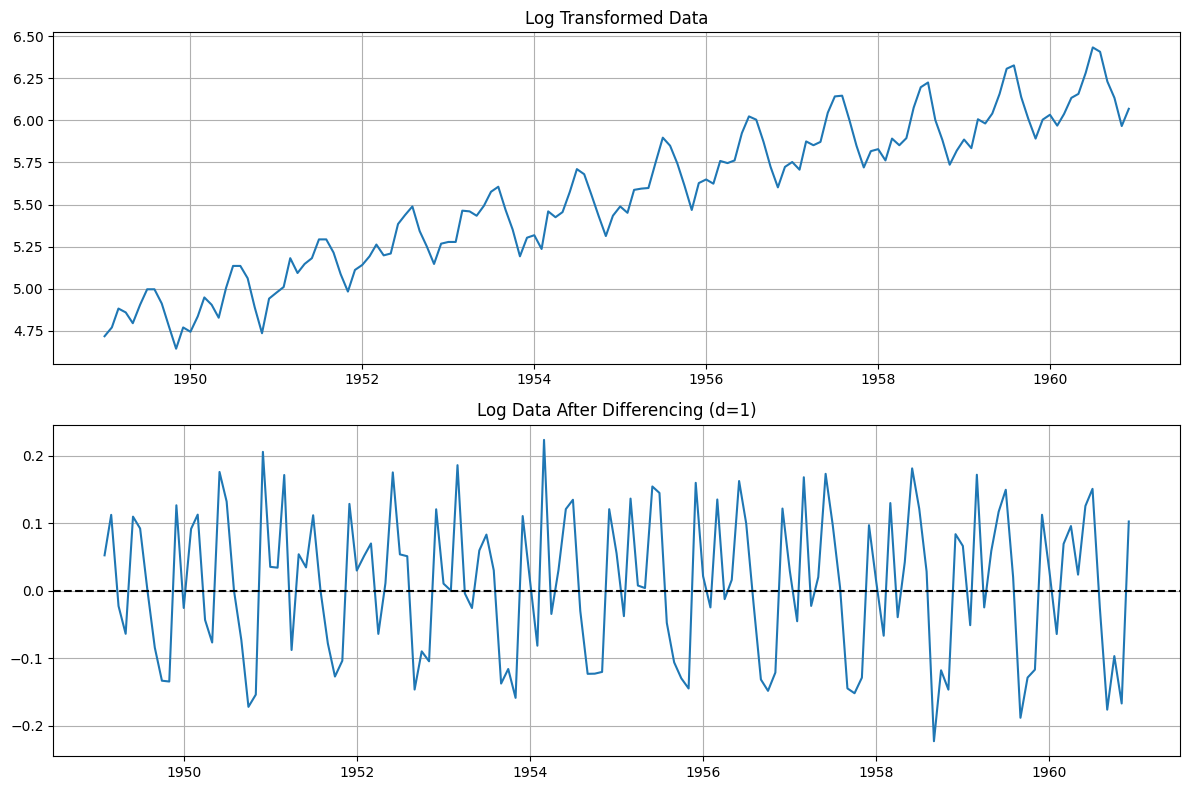

--- Differenced Log Data Test ---
ADF Statistic: -3.0530
p-value: 0.0302
Critical Values:
1%: -3.4817
5%: -2.8840
10%: -2.5788
Result: Data is STATIONARY (Reject H0)
--------------------------------------------------
--- Differenced Log Data Test ---
KPSS Statistic: 0.0383
p-value: 0.1000
Critical Values:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390
Result: Data is STATIONARY (Fail to reject H0)


In [22]:
# Log transformation to stabilize variance
df['Log_Passengers'] = np.log(df['Passengers'])

# Differencing to stabilize mean
df['Log_Diff'] = df['Log_Passengers'].diff().dropna()

# Plot Transformed Data
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(df['Log_Passengers'])
axes[0].set_title('Log Transformed Data')

axes[1].plot(df['Log_Diff'])
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('Log Data After Differencing (d=1)')

plt.tight_layout()
plt.show()

print("--- Differenced Log Data Test ---")
adf_test(df['Log_Diff'].dropna())
print("-"*50)
print("--- Differenced Log Data Test ---")
kpss_test(df['Log_Diff'].dropna())

### Part 4: ACF & PACF
Identify AR(p) and MA(q) terms using the stationary series.

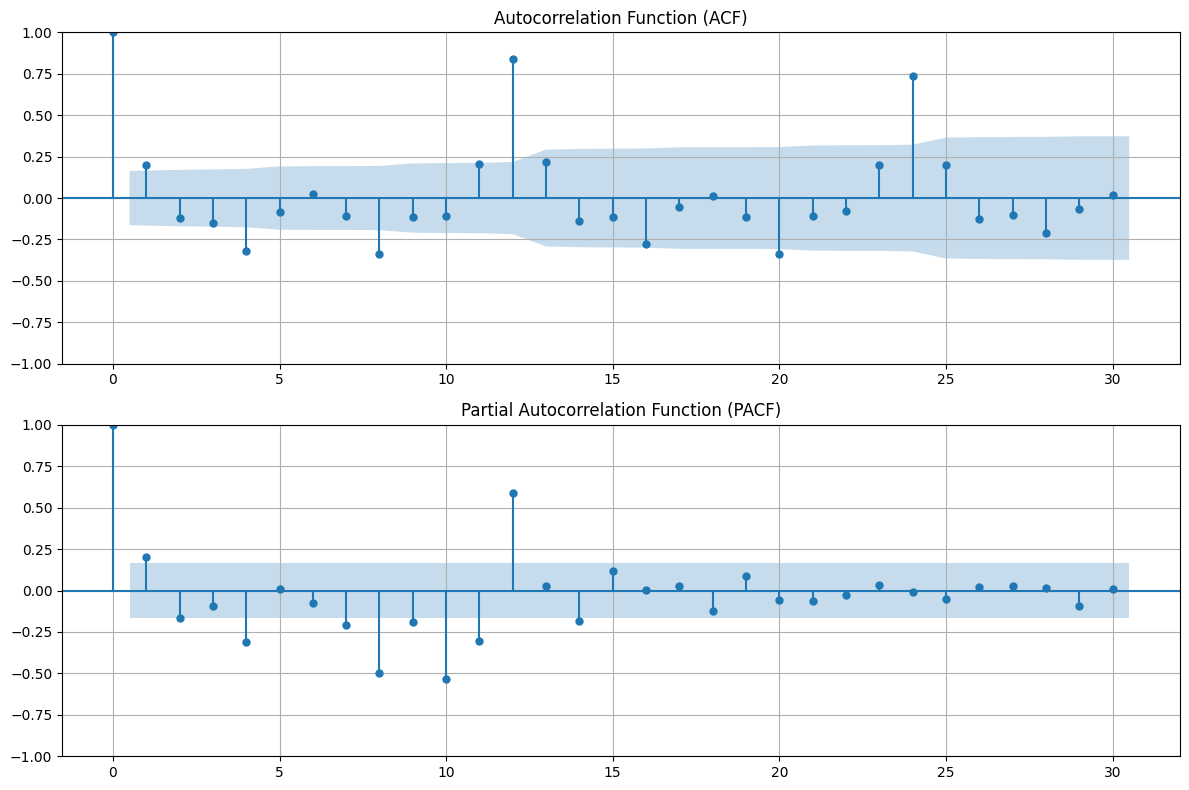

In [104]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(df['Log_Diff'].dropna(), lags=30, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF)')

plot_pacf(df['Log_Diff'].dropna(), lags=30, ax=ax2)
ax2.set_title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()

### Part 5: ARIMA Modeling
Split data and fit an ARIMA(1,1,1) baseline model on the Log-transformed data.

In [105]:
train_ratio = 0.8
last_train_index = int(len(df) * train_ratio)
train, test = df[:last_train_index], df[last_train_index:]
train.tail()

,Passengers,Log_Passengers,Log_Diff
Month,,,
1958-03-01,362,5.891644,0.129593
1958-04-01,348,5.852202,-0.039442
1958-05-01,363,5.894403,0.042200
1958-06-01,435,6.075346,0.180943
1958-07-01,491,6.196444,0.121098


In [106]:
model = ARIMA(train['Log_Passengers'], order=(1, 1, 0), seasonal_order=(1,1,1,12))
model_fit = model.fit()

print(model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                     Log_Passengers   No. Observations:                  115
Model:             ARIMA(1, 1, 0)x(1, 1, [1], 12)   Log Likelihood                 189.021
Date:                            Wed, 25 Feb 2026   AIC                           -370.042
Time:                                    01:28:19   BIC                           -359.542
Sample:                                01-01-1949   HQIC                          -365.790
                                     - 07-01-1958                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3026      0.078     -3.862      0.000      -0.456      -0.149
ar.S.L12      -0.0757      0.206   

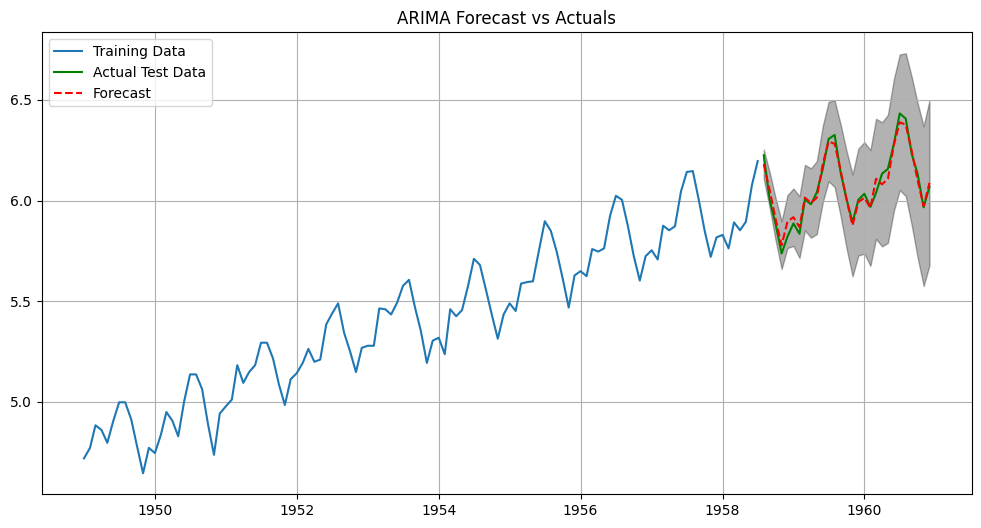

In [107]:
forecast_result = model_fit.get_forecast(steps=len(test))
forecast_values_log = forecast_result.predicted_mean
conf_int_log = forecast_result.conf_int()

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(train['Log_Passengers'], label='Training Data')
plt.plot(test['Log_Passengers'], label='Actual Test Data', color='green')
plt.plot(test.index, forecast_values_log, label='Forecast', color='red', linestyle='--')
plt.fill_between(test.index, conf_int_log.iloc[:, 0], conf_int_log.iloc[:, 1], alpha=0.3,color='#000')

plt.title('ARIMA Forecast vs Actuals')
plt.legend()
plt.show()

In [108]:
mae = mean_absolute_error(test['Log_Passengers'], forecast_values_log)
rmse = np.sqrt(mean_squared_error(test['Log_Passengers'], forecast_values_log))
mape = np.mean(np.abs((test['Log_Passengers'] - forecast_values_log) / test['Log_Passengers'])) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 0.03
RMSE: 0.03
MAPE: 0.46%


## AutoARIMA

In [109]:
import pandas as pd
import numpy as np

df = pd.read_csv("dataset/AirPassengers.csv")

df.columns = ['Month', 'Passengers']
df['Log_Passengers'] = np.log(df['Passengers'])
df['Month'] = pd.to_datetime(df['Month'])
df = df.set_index('Month')
df.head()

,Passengers,Log_Passengers
Month,,
1949-01-01,112,4.718499
1949-02-01,118,4.770685
1949-03-01,132,4.882802
1949-04-01,129,4.859812
1949-05-01,121,4.795791


In [110]:
train_ratio = 0.8
last_train_index = int(len(df) * train_ratio)
train, test = df[:last_train_index], df[last_train_index:]
train.tail()

,Passengers,Log_Passengers
Month,,
1958-03-01,362,5.891644
1958-04-01,348,5.852202
1958-05-01,363,5.894403
1958-06-01,435,6.075346
1958-07-01,491,6.196444


In [111]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsforecast.arima import arima_string

pipeline = StatsForecast(
    models=[AutoARIMA(season_length=12)],
    freq='MS',
    n_jobs=-1
)
train_df = pd.DataFrame({'ds':train.index, 'y':train.Log_Passengers, 'unique_id':'train'})
test_df = pd.DataFrame({'ds':test.index, 'y':test.Log_Passengers, 'unique_id':'test'})

In [112]:
pipeline.fit(df=train_df)
arima_string(pipeline.fitted_[0, 0].model_)

'ARIMA(2,0,0)(0,1,1)[12] with drift        '

In [113]:
forecast_df = pipeline.predict(h=len(test_df), level=[95])

In [114]:
mae = mean_absolute_error(test['Log_Passengers'], forecast_df['AutoARIMA'])
rmse = np.sqrt(mean_squared_error(test['Log_Passengers'], forecast_df['AutoARIMA']))
mape = np.mean(np.abs((test['Log_Passengers'] - forecast_df['AutoARIMA']) / test['Log_Passengers'])) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 0.08
RMSE: 0.09
MAPE: nan%


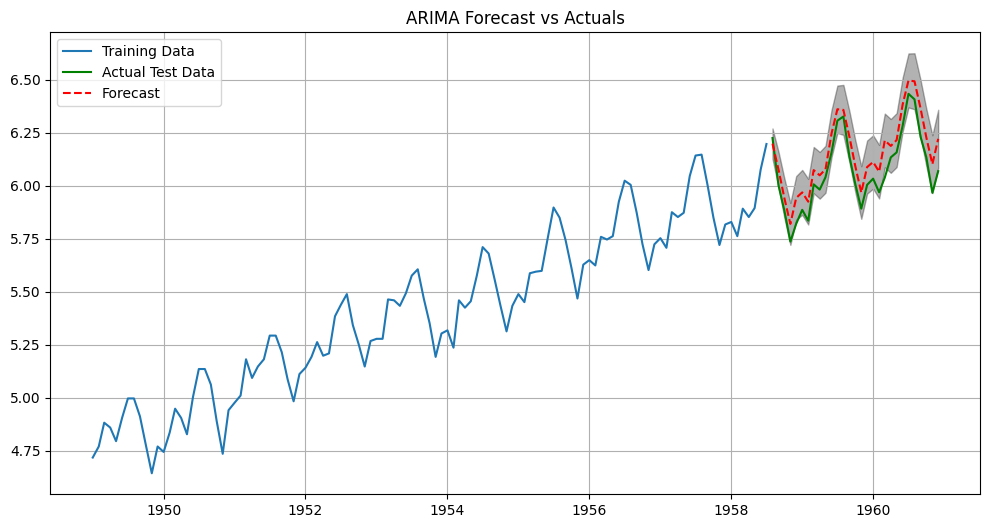

  Using cached statsmodels-0.14.6-cp311-cp311-win_amd64.whl.metadata (9.8 kB)
  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached statsforecast-2.0.3-cp311-cp311-win_amd64.whl.metadata (29 kB)
  Using cached numpy-2.4.2-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached pandas-3.0.1-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
  Using cached packaging-26.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp311-cp311-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp311-cp311-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.1.1-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastembed 0.7.4 requires pillow<12.0,>=10.3.0; python_version >= "3.10" and python_version < "3.13", but you have pillow 12.1.1 which is incompatible.
langchain-core 1.2.6 requires packaging<26.0.0,>=23.2.0, but you have packaging 26.0 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\abdel\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(train['Log_Passengers'], label='Training Data')
plt.plot(test['Log_Passengers'], label='Actual Test Data', color='green')
plt.plot(test.index, forecast_df['AutoARIMA'], label='Forecast', color='red', linestyle='--')
plt.fill_between(test.index, forecast_df['AutoARIMA-lo-95'], forecast_df['AutoARIMA-hi-95'], alpha=0.3,color='#000')

plt.title('ARIMA Forecast vs Actuals')
plt.legend()
plt.show()